<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-attack-risk-prediction-in-indonesia-ml-73-81?scriptVersionId=228274480" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-prediction-in-indonesia/heart_attack_prediction_indonesia.csv


## Title: Predicting Heart Attacks in Indonesia: A Data-Driven Approach

##### Description:
**This study focuses on predicting heart attack risks in Indonesia using machine learning techniques. By analyzing key health indicators, lifestyle factors, and medical history, the model aims to identify high-risk individuals and support early intervention strategies. The insights can help healthcare professionals improve patient outcomes and optimize preventive measures.**

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/heart-attack-prediction-in-indonesia/heart_attack_prediction_indonesia.csv')

In [3]:
df.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [4]:
df.tail()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
158350,60,Female,Rural,Middle,0,0,199,0,79,0,...,74,79,52,238,234,Normal,0,1,0,0
158351,64,Female,Urban,Low,0,0,179,0,93,0,...,73,111,41,177,239,Normal,0,1,1,1
158352,30,Male,Urban,Middle,0,0,220,0,78,0,...,87,127,50,158,201,Abnormal,1,1,1,1
158353,74,Male,Urban,Middle,0,0,180,0,58,1,...,70,119,52,153,171,Normal,1,0,1,1
158354,61,Male,Urban,Middle,0,0,190,0,81,0,...,81,95,49,125,149,Abnormal,0,0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  object 
 11  alcohol_consumption             63507 non-null   object 
 12  physical_activit

In [6]:
df.describe()

,age,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
count,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000
mean,54.543778,0.299069,0.199804,199.533264,0.249901,93.268504,0.300218,6.480064,129.515772,79.490809,110.736762,49.491478,129.569916,149.715885,0.200575,0.499770,0.601029,0.401004
std,11.910897,0.457851,0.399854,39.737565,0.432957,16.382205,0.458354,1.425398,15.005641,10.002964,27.673445,9.982634,34.913318,49.023473,0.400432,0.500002,0.489688,0.490103
min,25.000000,0.000000,0.000000,100.000000,0.000000,20.000000,0.000000,3.000000,61.000000,37.000000,70.000000,8.000000,-19.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,172.000000,0.000000,82.000000,0.000000,5.492985,119.000000,73.000000,89.000000,43.000000,106.000000,116.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,0.000000,0.000000,199.000000,0.000000,93.000000,0.000000,6.507461,130.000000,80.000000,109.000000,49.000000,130.000000,149.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,1.000000,0.000000,226.000000,0.000000,104.000000,1.000000,7.520640,140.000000,86.000000,130.000000,56.000000,153.000000,183.000000,0.000000,1.000000,1.000000,1.000000
max,90.000000,1.000000,1.000000,350.000000,1.000000,173.000000,1.000000,9.000000,199.000000,127.000000,230.000000,93.000000,282.000000,380.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

age                                   0
gender                                0
region                                0
income_level                          0
hypertension                          0
diabetes                              0
cholesterol_level                     0
obesity                               0
waist_circumference                   0
family_history                        0
smoking_status                        0
alcohol_consumption               94848
physical_activity                     0
dietary_habits                        0
air_pollution_exposure                0
stress_level                          0
sleep_hours                           0
blood_pressure_systolic               0
blood_pressure_diastolic              0
fasting_blood_sugar                   0
cholesterol_hdl                       0
cholesterol_ldl                       0
triglycerides                         0
EKG_results                           0
previous_heart_disease                0


In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

age                                 int64
gender                             object
region                             object
income_level                       object
hypertension                        int64
diabetes                            int64
cholesterol_level                   int64
obesity                             int64
waist_circumference                 int64
family_history                      int64
smoking_status                     object
alcohol_consumption                object
physical_activity                  object
dietary_habits                     object
air_pollution_exposure             object
stress_level                       object
sleep_hours                       float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
fasting_blood_sugar                 int64
cholesterol_hdl                     int64
cholesterol_ldl                     int64
triglycerides                       int64
EKG_results                       

In [10]:
df.shape

(158355, 28)

In [11]:
df.columns 

Index(['age', 'gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'cholesterol_level', 'obesity', 'waist_circumference', 'family_history',
       'smoking_status', 'alcohol_consumption', 'physical_activity',
       'dietary_habits', 'air_pollution_exposure', 'stress_level',
       'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'EKG_results', 'previous_heart_disease',
       'medication_usage', 'participated_in_free_screening', 'heart_attack'],
      dtype='object')

## Data visualizations

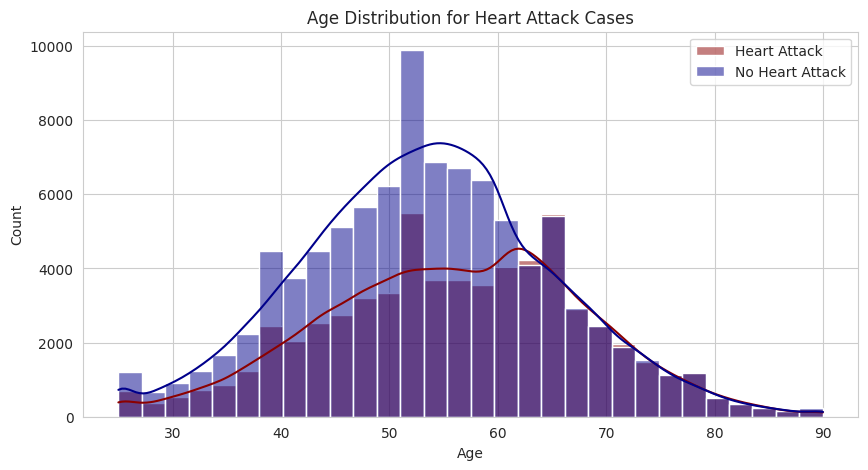

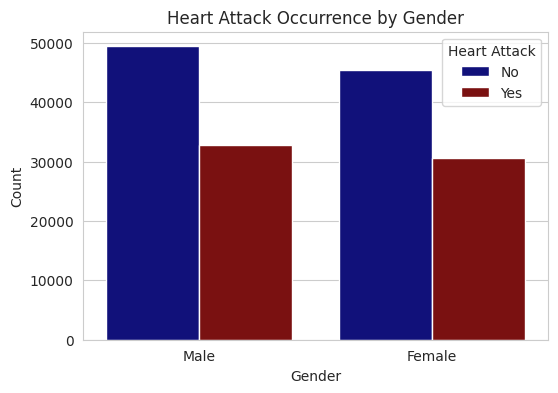

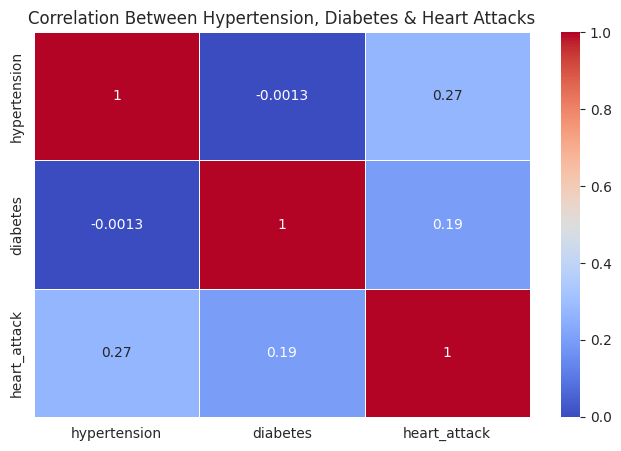

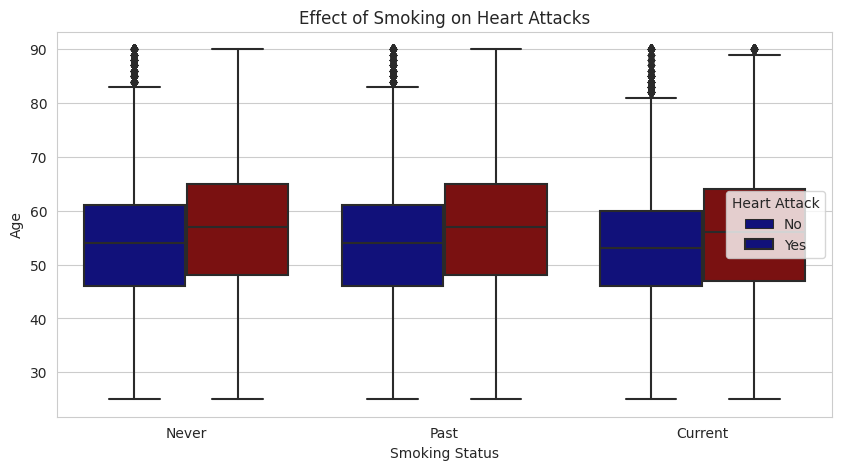

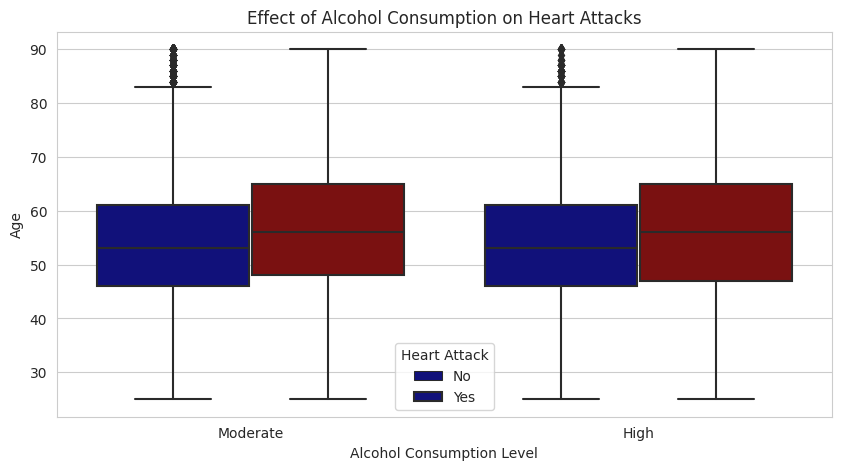

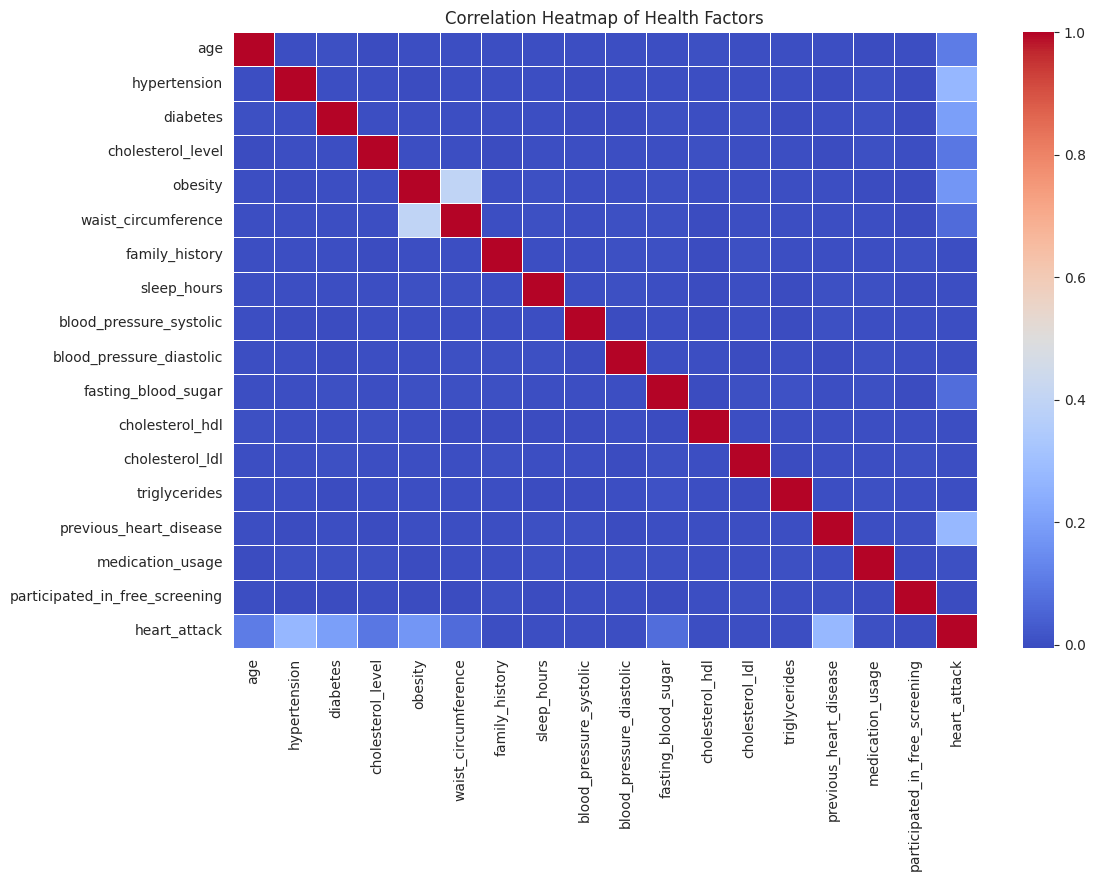

In [12]:
# Set a consistent style
sns.set_style("whitegrid")

# 1. Age Distribution for Heart Attack Cases
plt.figure(figsize=(10, 5))
sns.histplot(df[df["heart_attack"] == 1]["age"], bins=30, color="darkred", kde=True, label="Heart Attack")
sns.histplot(df[df["heart_attack"] == 0]["age"], bins=30, color="darkblue", kde=True, label="No Heart Attack")
plt.legend()
plt.title("Age Distribution for Heart Attack Cases")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 2. Gender-wise Heart Attack Occurrence
plt.figure(figsize=(6, 4))
sns.countplot(x="gender", hue="heart_attack", data=df, palette=["darkblue", "darkred"])
plt.title("Heart Attack Occurrence by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Heart Attack", labels=["No", "Yes"])
plt.show()

# 3. Hypertension & Diabetes Effect
plt.figure(figsize=(8, 5))
sns.heatmap(df[["hypertension", "diabetes", "heart_attack"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Hypertension, Diabetes & Heart Attacks")
plt.show()

# 4. Smoking & Alcohol Consumption Impact
plt.figure(figsize=(10, 5))
sns.boxplot(x="smoking_status", y="age", hue="heart_attack", data=df, palette=["darkblue", "darkred"])
plt.title("Effect of Smoking on Heart Attacks")
plt.xlabel("Smoking Status")
plt.ylabel("Age")
plt.legend(title="Heart Attack", labels=["No", "Yes"])
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="alcohol_consumption", y="age", hue="heart_attack", data=df, palette=["darkblue", "darkred"])
plt.title("Effect of Alcohol Consumption on Heart Attacks")
plt.xlabel("Alcohol Consumption Level")
plt.ylabel("Age")
plt.legend(title="Heart Attack", labels=["No", "Yes"])
plt.show()

# 5. Correlation Heatmap for Key Features
numeric_cols = df.select_dtypes(include=['number']).columns  # Exclude categorical variables
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of Health Factors")
plt.show()

## Predictive modeling

Here’s the full machine learning pipeline to process the dataset:

Train-test split (80-20 split)

Label encoding (for categorical variables)

Applying multiple ML models and comparing their accuracy

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [14]:
# 2. Handle categorical features using Label Encoding
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store the encoders if needed later

In [15]:
# 3. Define Features & Target
X = df.drop(columns=["heart_attack"])
y = df["heart_attack"]

In [16]:
# 4. Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# 5. Standardize numerical features (Optional for tree models, necessary for SVM, Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# 6. Initialize ML Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC()
}

In [19]:
# 7. Train and Evaluate Models
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy


In [20]:
# 8. Display Accuracy Results
accuracy_df = pd.DataFrame(accuracy_results.items(), columns=["Model", "Accuracy"])
accuracy_df = accuracy_df.sort_values(by="Accuracy", ascending=False)

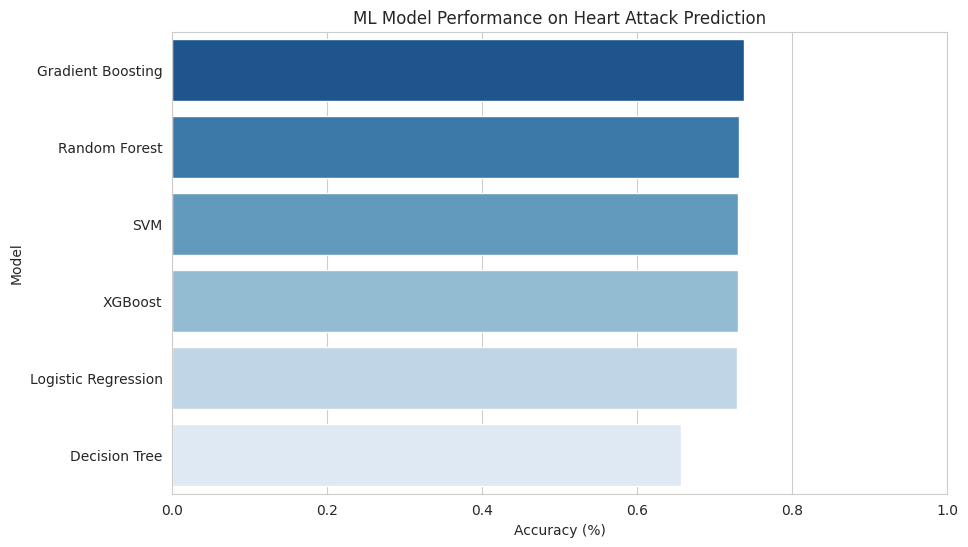

In [21]:
# 9. Visualization - Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=accuracy_df, palette="Blues_r")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("ML Model Performance on Heart Attack Prediction")
plt.xlim(0, 1)  # Set limits from 0 to 1
plt.show()

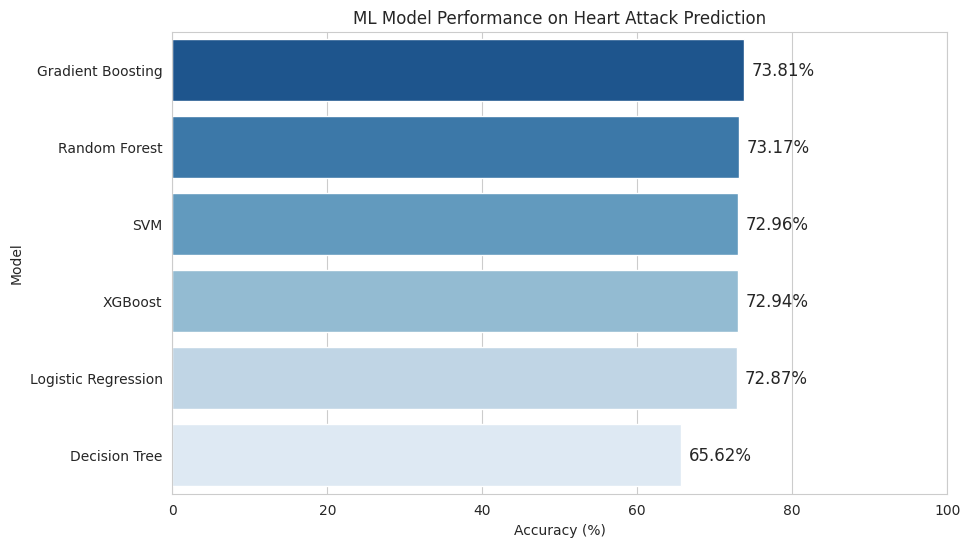

In [22]:
accuracy_df["Accuracy"] = accuracy_df["Accuracy"] * 100

# Visualization - Bar Chart with Percentage
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=accuracy_df, palette="Blues_r")

# Show percentage labels on bars
for index, value in enumerate(accuracy_df["Accuracy"]):
    plt.text(value + 1, index, f"{value:.2f}%", va="center", fontsize=12)

plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.title("ML Model Performance on Heart Attack Prediction")
plt.xlim(0, 100)  # Set limits from 0 to 100
plt.show()

## Thank you...!!!! Pls upvote..!!!